In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

[ 1. 16.]


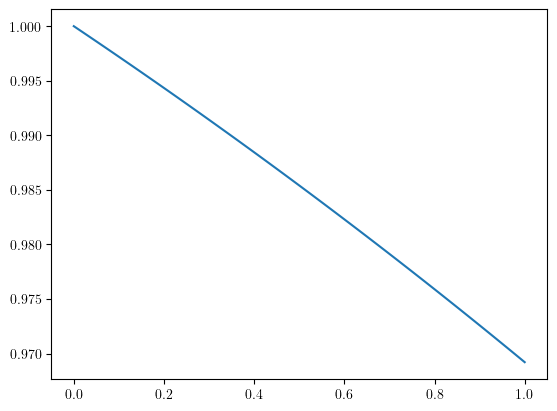

In [17]:
Data = np.load('Datos_Funcionalidad.npy')
Data2 = np.load('Datos_Lambda.npy')
print(Data2)

plt.plot(Data[0],Data[1])

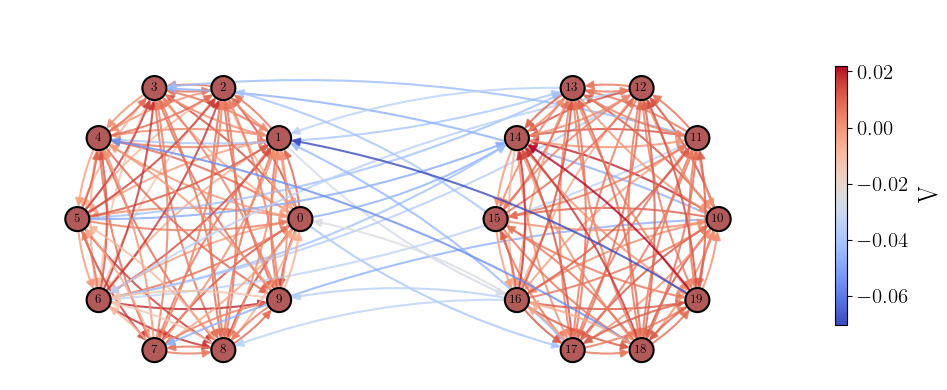

In [21]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --------------------------------------------------
# CARGAR DATOS
# --------------------------------------------------

A = np.load('../A_origin.npy')
Resultados = np.load('Datos_Antifragilidad.npy')

# Crear grafo dirigido
G = nx.from_numpy_array(A, create_using=nx.DiGraph)

# --------------------------------------------------
# ASIGNAR ANTIFRAGILIDAD A CADA ENLACE
# --------------------------------------------------

for fila in Resultados:

    u = int(fila[0])
    v = int(fila[1])
    Lambda = float(fila[2])

    if G.has_edge(u, v):
        G[u][v]["Lambda"] = Lambda

# --------------------------------------------------
# POSICIONES (MISMO ESTILO DE DOS COMUNIDADES)
# --------------------------------------------------

N_com = 10

pos = {}

for i in range(N_com):

    angle = 2*np.pi*i/N_com

    pos[i] = np.array([
        -1.5 + 0.8*np.cos(angle),
        0.8*np.sin(angle)
    ])

for i in range(N_com, 2*N_com):

    angle = 2*np.pi*(i-N_com)/N_com

    pos[i] = np.array([
        1.5 + 0.8*np.cos(angle),
        0.8*np.sin(angle)
    ])

# --------------------------------------------------
# CONFIGURACIÓN DE FIGURA
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10,4),
    facecolor='white'
)

node_colors = ['#B25A5A']*(2*N_com)

# --------------------------------------------------
# EXTRAER ENLACES Y ANTIFRAGILIDADES
# --------------------------------------------------

edges = list(G.edges())

Lambda_edges = np.array([
    G[u][v]["Lambda"]
    for u,v in edges
])

# --------------------------------------------------
# NODOS
# --------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=300,
    node_color=node_colors,
    edgecolors='black',
    linewidths=1.5
)

# --------------------------------------------------
# ENLACES
# --------------------------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edgelist=edges,
    width=1.5,
    edge_color=Lambda_edges,
    edge_cmap=plt.cm.coolwarm,
    edge_vmin=np.min(Lambda_edges),
    edge_vmax=np.max(Lambda_edges),
    arrowstyle='-|>',
    arrowsize=12,
    connectionstyle='arc3,rad=0.1',
    alpha=0.8
)

# --------------------------------------------------
# ETIQUETAS
# --------------------------------------------------

nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    font_size=9,
    font_color='black',
    font_weight='bold'
)

# --------------------------------------------------
# COLORBAR
# --------------------------------------------------

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.coolwarm,
    norm=plt.Normalize(
        vmin=np.min(Lambda_edges),
        vmax=np.max(Lambda_edges)
    )
)

sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    shrink=0.7
)

cbar.set_label(
    r'$\Lambda$',
    rotation=270,
    labelpad=20,
    fontsize=20
)

cbar.ax.tick_params(labelsize=15)

# --------------------------------------------------
# FINAL
# --------------------------------------------------

ax.axis('off')

plt.tight_layout()

plt.savefig(
    'Antifragilidad_enlaces.pdf',
    bbox_inches='tight'
)

plt.show()